# Customer Shopping Behavior Analysis

## Project Objective

The objective of this project is to analyze customer shopping behavior using Python. We perform data cleaning, feature engineering, exploratory data analysis (EDA), and visualization to identify purchasing patterns, customer demographics, product preferences, and business insights.

## Step 1: Import Required Libraries

In this step, we import the Python libraries required for data analysis and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

Load the customer shopping behavior dataset into a Pandas DataFrame.

In [ ]:
#Step 2: Load the dataset
df = pd.read_csv("shopping_behavior.csv")

## Step 3: Display the Dataset

Display the first few rows to understand the structure of the dataset.

In [ ]:
#Step 3: View the first 5 rows
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
#Step 4: Check dataset size
df.shape

(3900, 18)

In [ ]:
#Step 5: View column names
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

## Step 4: Explore the Dataset

Check the dataset's structure, column names, data types, and summary statistics.

In [ ]:
#Step 6: Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

## Step 5: Check for Duplicate Records

Identify whether duplicate rows exist in the dataset.

In [ ]:
#Step 7: Check duplicates
df.duplicated().sum()

np.int64(0)

## Step 7: Check Missing Values

Identify missing values present in each column.

In [ ]:
#Step 8: Check missing values
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

## Step 8: Handle Missing Values

Replace missing values in the Review Rating column with the mean value.

In [ ]:
#Step 9: Fill missing value
df["Review Rating"] = df["Review Rating"].fillna(df["Review Rating"].median())

## Step 9: Verify Data Cleaning

Ensure that all missing values have been handled successfully.

In [ ]:
#Step 10: Check missing values after filling
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

## Step 10: Feature Engineering

Create customer age groups for better analysis.

In [12]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"]
)

## Step 11: Verify Age Groups

Display the Age and Age Group columns.

In [37]:
df[["Age","Age Group"]].head(10)

,Age,Age Group
0,55,51-70
1,19,18-25
2,50,36-50
3,21,18-25
4,45,36-50
5,46,36-50
6,63,51-70
7,27,26-35
8,26,26-35
9,57,51-70


How many customers belong to each age group?

In [14]:
df["Age Group"].value_counts()

Age Group
51-70    1476
36-50    1111
26-35     742
18-25     571
Name: count, dtype: int64

## Step 12: Customer Distribution by Age Group

Analyze the number of customers in each age group.

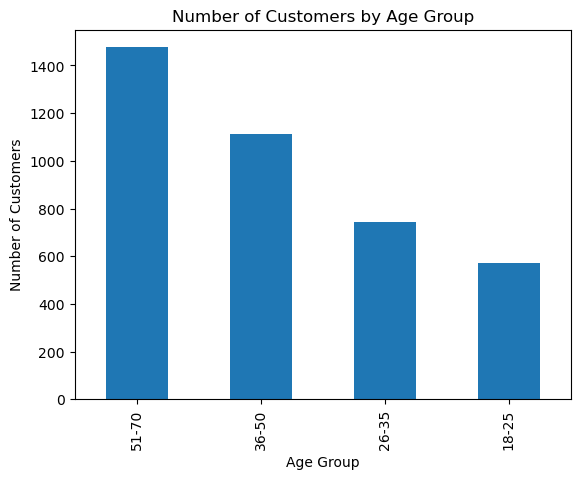

In [15]:
import matplotlib.pyplot as plt

df["Age Group"].value_counts().plot(kind="bar")

plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
Which age group generates the highest revenue?

In [16]:
age_sales = df.groupby("Age Group")["Purchase Amount (USD)"].sum()

age_sales

C:\Users\Ambika\AppData\Local\Temp\ipykernel_24636\3738636830.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby("Age Group")["Purchase Amount (USD)"].sum()


Age Group
18-25    34630
26-35    44342
36-50    65629
51-70    88480
Name: Purchase Amount (USD), dtype: int64

## Step 13: Revenue Analysis by Age Group

Calculate total revenue generated by each age group.

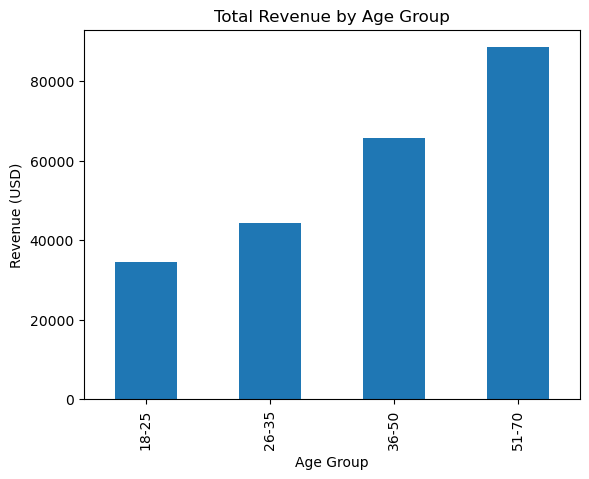

In [17]:
age_sales.plot(kind="bar")

plt.title("Total Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue (USD)")

plt.show()

## Step 14: Revenue Analysis by Gender

Compare revenue generated by male and female customers.

In [18]:
gender_sales = df.groupby("Gender")["Purchase Amount (USD)"].sum()

gender_sales

Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64

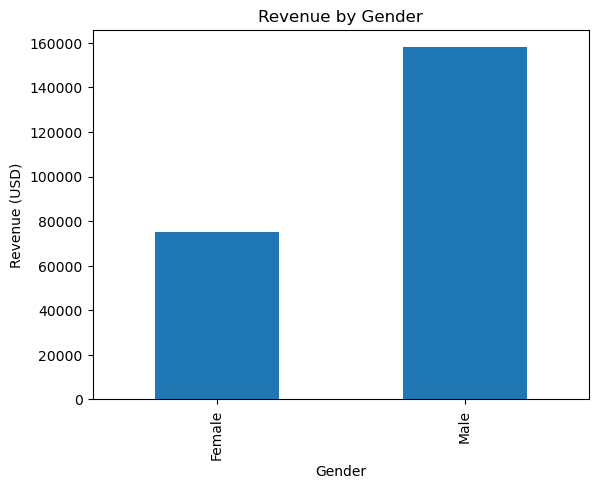

In [19]:
gender_sales.plot(kind="bar")

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue (USD)")

plt.show()

## Step 15: Revenue Analysis by Product Category

Identify which product categories generate the highest revenue.

In [20]:
category_sales = df.groupby("Category")["Purchase Amount (USD)"].sum()

category_sales

Category
Accessories     74200
Clothing       104264
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

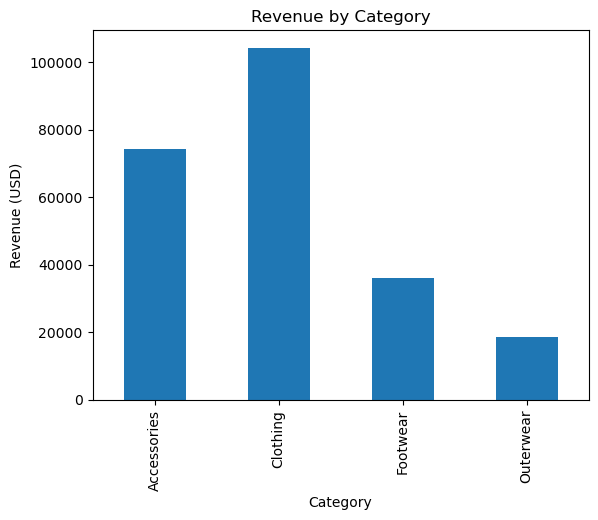

In [21]:
category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (USD)")

plt.show()

## Step 16: Subscription Status Analysis

Analyze how many customers have active subscriptions.

In [22]:
subscription = df["Subscription Status"].value_counts()

subscription

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

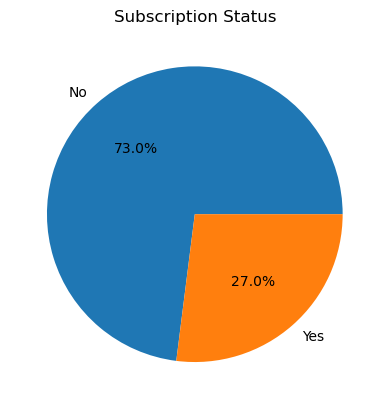

In [23]:
subscription.plot(kind="pie", autopct="%1.1f%%")

plt.title("Subscription Status")

plt.ylabel("")

plt.show()

## Step 17: Payment Method Analysis

Identify the most commonly used payment methods.

In [24]:
payment = df["Payment Method"].value_counts()

payment

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

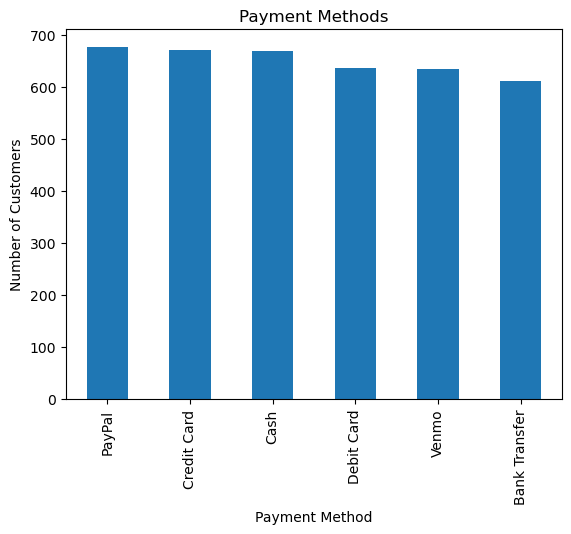

In [25]:
payment.plot(kind="bar")

plt.title("Payment Methods")

plt.xlabel("Payment Method")

plt.ylabel("Number of Customers")

plt.show()

## Step 18: Seasonal Revenue Analysis

Compare revenue generated across different seasons.

In [26]:
season_sales = df.groupby("Season")["Purchase Amount (USD)"].sum()

season_sales

Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64

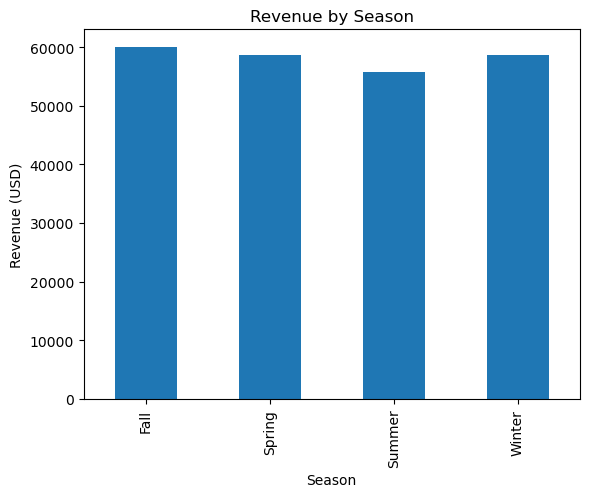

In [27]:
season_sales.plot(kind="bar")

plt.title("Revenue by Season")

plt.xlabel("Season")

plt.ylabel("Revenue (USD)")

plt.show()

## Step 19: Top Purchased Products

Identify the most frequently purchased products.

In [28]:
top_products = df["Item Purchased"].value_counts().head(10)

top_products

Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Name: count, dtype: int64

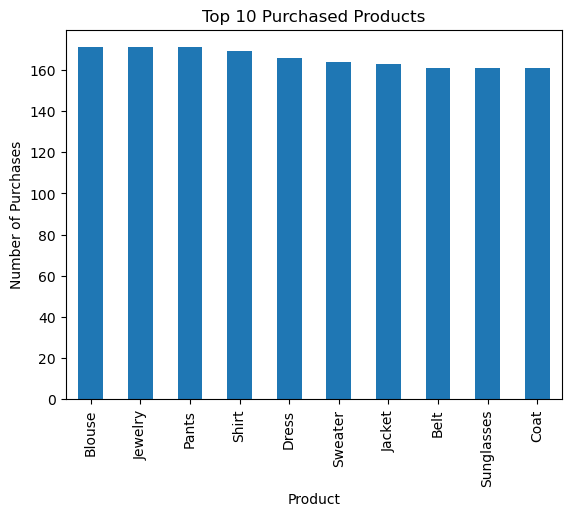

In [29]:
top_products.plot(kind="bar")

plt.title("Top 10 Purchased Products")
plt.xlabel("Product")
plt.ylabel("Number of Purchases")

plt.show()

## Step 20: Customer Review Analysis

Calculate the average review rating for each product category.

In [30]:
rating = df.groupby("Category")["Review Rating"].mean()

rating

Category
Accessories    3.770242
Clothing       3.722395
Footwear       3.793823
Outerwear      3.745988
Name: Review Rating, dtype: float64

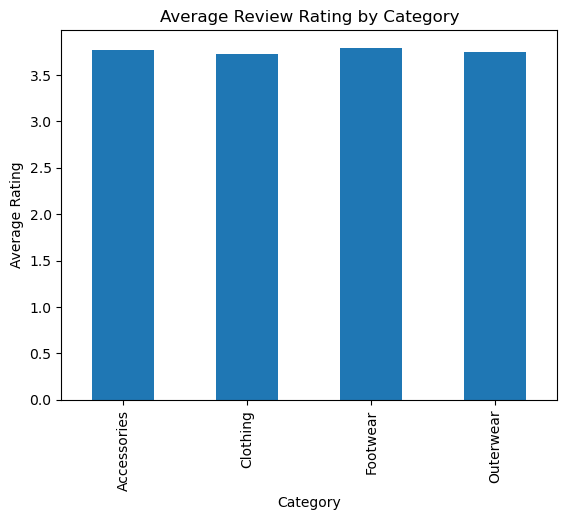

In [31]:
rating.plot(kind="bar")

plt.title("Average Review Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.show()

## Step 21: Discount Analysis

Analyze how many purchases were made with and without discounts.

In [32]:
discount = df["Discount Applied"].value_counts()

discount

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

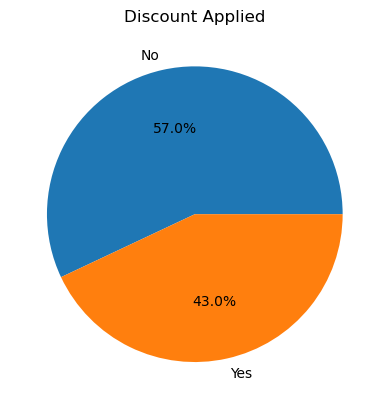

In [33]:
discount.plot(kind="pie",autopct="%1.1f%%")

plt.title("Discount Applied")

plt.ylabel("")

plt.show()

## Step 22: Save the Cleaned Dataset

Export the cleaned dataset for future analysis.

In [34]:
df.to_csv("shopping_behavior_cleaned.csv", index=False)

# Business Insights

- Customers aged 51–70 contribute the highest revenue.
- Male customers generate more revenue than female customers.
- Clothing is the highest revenue-generating category.
- Most customers are not subscribed.
- Payment methods are used almost equally.
- Sales remain consistent across all seasons.
- Blouse, Jewelry, Pants, Shirt, and Dress are among the most purchased products.
- Average customer ratings are around 3.7–3.8.
- Around 43% of customers purchased using discounts.

# Conclusion

This project analyzed customer shopping behavior using Python. Data cleaning, feature engineering, and exploratory data analysis (EDA) were performed to understand customer demographics, purchasing patterns, product preferences, and business trends.

The insights from this analysis can help businesses improve marketing strategies, inventory management, customer engagement, and decision-making.

In [2]:
import pandas as pd
import sqlite3

# 1. Reload the cleaned CSV data so the notebook remembers it
df = pd.read_csv("shopping_behavior_cleaned.csv")

# 2. Connect to your database
conn = sqlite3.connect("customer_shopping.db")

# 3. Convert your cleaned DataFrame into a SQL table
df.to_sql("customer_shopping", conn, if_exists="replace", index=False)

print("Database and table created successfully!")

# 4. Close the connection
conn.close()

Database and table created successfully!


In [3]:
import pandas as pd
import sqlite3

# 1. Connect to your database file
conn = sqlite3.connect("customer_shopping.db")

# 2. Write your SQL query here and read it with pandas
query = "SELECT * FROM customer_shopping LIMIT 5;"
df_result = pd.read_sql_query(query, conn)

# 3. Close connection and show the table rows
conn.close()
df_result

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,51-70
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,36-50
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-25
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,36-50
